# Hybrid spelling and punctuation assistant

This notebook is the main experiment surface for the current project architecture.

The project uses one final system:

```text
HybridCorrector = candidate generator + top-k edit Transformer + source-aware punctuation head + RuBERT context reranker + quality guard
```

The model does not rewrite the whole sentence. It predicts local token edits from top-k candidates and source-aware punctuation labels. v7.1 uses CPU-first RuBERT reranking, safer runtime gates, and rank-consistent top-k labels, safer split-candidates, whole-line/window runtime, protected punctuation gaps, RuBERT context reranking, full word-decision diagnostics, morphology-guarded dictionary gates, candidate-aware KEEP training and clean-noise filtering. Keyboard-neighbor typos are intentionally not used.


## 1. Environment

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Jupyter keeps imported modules in memory. After code changes we must force
# the kernel to import the current files from src/, otherwise old model classes
# can be used and cell 20 may fail while loading/evaluating the model.
PROJECT_MODULES = [
    "candidate_generator",
    "data_preparation",
    "edit_labels",
    "evaluate_hybrid",
    "hybrid_corrector",
    "hybrid_model",
    "hybrid_preprocessor",
    "morphology_guard",
    "quality_guard",
    "text_utils",
    "train_hybrid",
    "training_augmentation",
]
def reload_project_modules(names=None):
    names = PROJECT_MODULES if names is None else names
    for module_name in names:
        sys.modules.pop(module_name, None)

reload_project_modules()

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
warnings.filterwarnings("ignore", message=".*Some weights of.*BertForMaskedLM.*")
try:
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Project root:", ROOT)

for folder in ["models", "report", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)


Python: 3.10.12
TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /home/daniil/projects/ai-assistant


## 2. Experiment Configuration

Change hyperparameters here before running the rest of the notebook.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data paths
DATASET_PATH = Path("data/processed/dataset.csv")
TRAIN_PATH = Path("data/processed/train.csv")
VAL_PATH = Path("data/processed/val.csv")
TEST_PATH = Path("data/processed/test.csv")
RAW_TEXTS_PATH = Path("data/raw/texts.txt")

# Dataset regeneration from data/raw/texts.txt
REGENERATE_DATASET = True
SAMPLES_PER_TEXT = 4
TRAIN_CLEAN_RATIO = 0.40
EVAL_CLEAN_RATIO = 0.35

TRAIN_CURRICULUM = [
    {"name": "spelling_light", "profile": "spelling_light", "p": 0.20},
    {"name": "spelling_medium", "profile": "spelling_medium", "p": 0.18},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.22},
    {"name": "mixed", "profile": "mixed", "p": 0.20},
    {"name": "space_errors", "profile": "space_errors", "p": 0.12},
    {"name": "hard", "profile": "hard", "p": 0.08},
]

EVAL_CURRICULUM = [
    {"name": "spelling_light", "profile": "spelling_light", "p": 0.27},
    {"name": "spelling_medium", "profile": "spelling_medium", "p": 0.15},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.31},
    {"name": "mixed", "profile": "mixed", "p": 0.16},
    {"name": "space_errors", "profile": "space_errors", "p": 0.08},
    {"name": "hard", "profile": "hard", "p": 0.03},
]

# Hybrid labels and model
MODEL_VERSION = 8
MAX_LENGTH = 128
MIN_VOCAB_FREQ = 1
MAX_VOCAB_SIZE = 80_000
CANDIDATE_MIN_FREQ = 1
CANDIDATE_MAX_DISTANCE = 1
LONG_OOV_MAX_DISTANCE = 2
LONG_OOV_MIN_LENGTH = 8
CANDIDATE_TOP_K = 8
MIN_DICTIONARY_SCORE = 0.25
SAFE_SPLIT_CANDIDATES = True

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT_RATE = 0.30
LEARNING_RATE = 1e-4

# Candidate-aware KEEP augmentation
KEEP_CANDIDATE_AUGMENTATION = True
KEEP_CANDIDATE_PROBABILITY = 0.35
KEEP_CANDIDATE_MAX_PER_EXAMPLE = 3
KEEP_CANDIDATE_MAX_SEARCHES = 8_000
KEEP_CANDIDATE_CLEAN_ONLY = True
CLEAN_AUDIT_MAX_WORD_SEARCHES = 5_000

# Action and punctuation training weights
CLEAN_ACTION_KEEP_WEIGHT = 2.0
DIRTY_ACTION_KEEP_WEIGHT = 1.0
ACTION_CHANGE_WEIGHT = 3.0
PUNCT_CHANGE_WEIGHT = 8.0
FINAL_PUNCT_WEIGHT = 8.0
CLEAN_PUNCT_KEEP_WEIGHT = 2.0
DIRTY_PUNCT_KEEP_WEIGHT = 1.0

# Training
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 2

# Context reranker
CONTEXT_RERANKER_ENABLED = True
CONTEXT_MODEL_NAME = "DeepPavlov/rubert-base-cased"
CONTEXT_DEVICE = "cpu"  # cpu avoids CUDA conflicts with TensorFlow during evaluation
CONTEXT_MARGIN = 0.25
USE_ENTITY_GUARD = True
DETERMINISTIC_SPACING = True

# Evaluation
EVAL_SAMPLE_SIZE = None  # set None for full test split
STRICTNESS = "strict"  # strict | normal | aggressive
PUNCTUATION_MODE = "conservative"  # conservative | none | legacy

MODEL_PATH = Path("models/hybrid_corrector.keras")
PREPROCESSOR_PATH = Path("models/hybrid_preprocessor.pkl")
CANDIDATE_GENERATOR_PATH = Path("models/candidate_generator.pkl")
CONFIG_PATH = Path("models/hybrid_config.json")
TRAINING_LOG_PATH = Path("models/hybrid_training_log.csv")


## 3. Optional Dataset Regeneration

This cell uses the current project generator. It does not add keyboard-neighbor typos.


In [3]:
from data_preparation import DatasetGenerator, split_texts

if REGENERATE_DATASET:
    if not RAW_TEXTS_PATH.exists():
        raise FileNotFoundError(f"Missing raw texts: {RAW_TEXTS_PATH}")

    generator = DatasetGenerator()
    texts = generator.load_texts_from_file(str(RAW_TEXTS_PATH))
    train_texts, val_texts, test_texts = split_texts(
        texts,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        seed=SEED,
    )

    df_train = generator.generate_dataset_curriculum(
        train_texts,
        samples_per_text=SAMPLES_PER_TEXT,
        clean_ratio=TRAIN_CLEAN_RATIO,
        curriculum=TRAIN_CURRICULUM,
    )
    df_train["split"] = "train"

    df_val = generator.generate_dataset_curriculum(
        val_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_val["split"] = "val"

    df_test = generator.generate_dataset_curriculum(
        test_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_test["split"] = "test"

    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")

    print("Regenerated dataset:", len(df))
else:
    print("Dataset regeneration skipped.")


Генерация датасета (CURRICULUM)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47997/47997 [00:12<00:00, 3995.06it/s]


Создано 191988 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5999/5999 [00:00<00:00, 19170.28it/s]


Создано 5999 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6001/6001 [00:00<00:00, 20216.12it/s]


Создано 6001 примеров (curriculum)
Regenerated dataset: 203988


## 4. Load And Inspect Dataset

Dataset rows: 203988
Train/val/test: 191988 5999 6001


,error_text,correct_text,difficulty,error_types,split
0,"Именно ему,и приписывают автоорство идеи, но з...","Именно ему и приписывают авторство идеи, но са...",hard,spelling_replace|spelling_delete|spelling_repl...,train
1,"Именно ему, и приписываютавторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",space_errors,punct_extra_comma|space_merge_words|space_dupl...,train
2,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",clean,clean,train
3,"Ихменно ему и приписывают авторство идеи, но с...","Именно ему и приписывают авторство идеи, но са...",spelling_light,spelling_extra,train
4,По официальной информации Управления ветеринар...,По официальной информации Управления ветеринар...,spelling_light,spelling_double,train


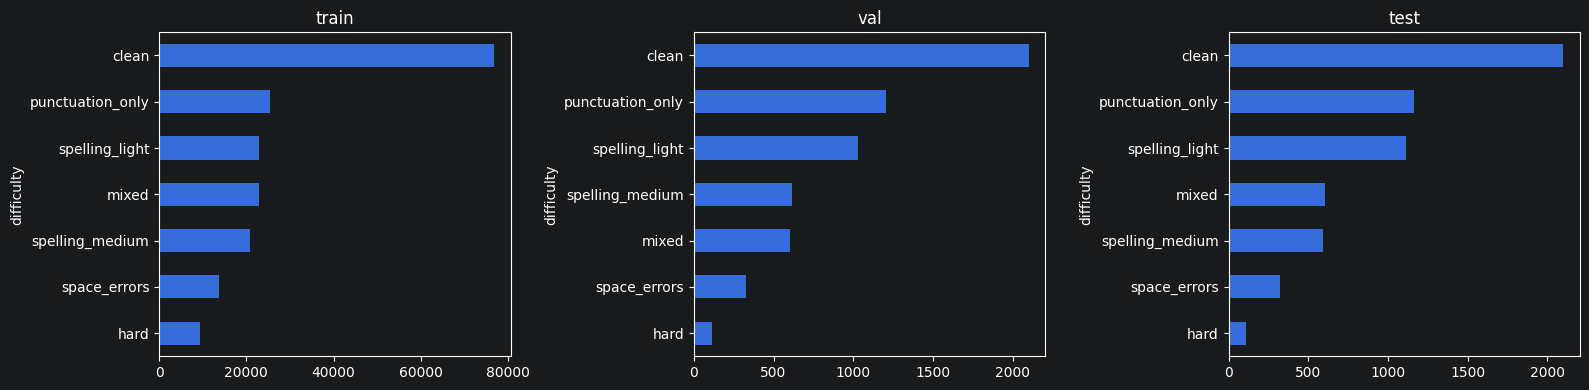

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH)
if "split" in df.columns:
    df_train = df[df["split"] == "train"].copy()
    df_val = df[df["split"] == "val"].copy()
    df_test = df[df["split"] == "test"].copy()
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_val = pd.read_csv(VAL_PATH)
    df_test = pd.read_csv(TEST_PATH)

print("Dataset rows:", len(df))
print("Train/val/test:", len(df_train), len(df_val), len(df_test))
display(df.head(5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, part, title in [
    (axes[0], df_train, "train"),
    (axes[1], df_val, "val"),
    (axes[2], df_test, "test"),
]:
    part["difficulty"].value_counts().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 5. Build Hybrid Training Labels

In [5]:
reload_project_modules(["candidate_generator", "edit_labels", "training_augmentation", "text_utils", "morphology_guard"])
from candidate_generator import CandidateGenerator
from edit_labels import build_examples_from_dataframe
from training_augmentation import filter_noisy_clean_rows

provisional_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=False,
)

all_rows = pd.concat([df_train, df_val, df_test], ignore_index=True)
_, clean_noise_audit, suspicious_texts = filter_noisy_clean_rows(
    all_rows,
    provisional_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_noise_filter_path = Path("report/clean_noise_filter.csv")
clean_noise_audit.to_csv(clean_noise_filter_path, index=False, encoding="utf-8")
print("Clean noise filter rows:", len(clean_noise_audit), "->", clean_noise_filter_path)

if suspicious_texts:
    df_train = df_train.loc[~df_train["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_val = df_val.loc[~df_val["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_test = df_test.loc[~df_test["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Filtered dataset rows:", len(df), "removed texts:", len(suspicious_texts))

train_examples, train_label_stats = build_examples_from_dataframe(df_train, max_tokens=MAX_LENGTH)
val_examples, val_label_stats = build_examples_from_dataframe(df_val, max_tokens=MAX_LENGTH)

print("Train label stats:", train_label_stats)
print("Val label stats:", val_label_stats)

if not train_examples or not val_examples:
    raise RuntimeError("Not enough aligned hybrid examples. Check dataset quality and MAX_LENGTH.")

if not hasattr(train_examples[0], "source_punct_labels"):
    raise RuntimeError("Stale edit_labels module detected. Rerun cell 2, then rerun cells 10-12.")

action_counter = Counter(label for ex in train_examples for label in ex.action_labels)
punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.target_punct_labels)
source_punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.source_punct_labels)

print("Action labels:", action_counter)
print("Source punctuation labels:", source_punct_counter)
print("Target punctuation labels:", punct_counter)
if len(clean_noise_audit):
    display(clean_noise_audit.head(10))


Clean noise filter rows: 758 -> report/clean_noise_filter.csv
Filtered dataset rows: 201421 removed texts: 758
Train label stats: {'rows': 189576, 'kept': 187509, 'skipped': 2067, 'clean': 75852}
Val label stats: {'rows': 5932, 'kept': 5884, 'skipped': 48, 'clean': 2078}
Action labels: Counter({'KEEP': 2484050, 'REPLACE_0': 126699, 'DELETE': 163})
Source punctuation labels: Counter({'NONE': 2251310, ',': 204624, '.': 147088, ':': 4554, '?': 2493, ';': 463, '!': 380})
Target punctuation labels: Counter({'NONE': 2244700, ',': 192460, '.': 165474, ':': 4678, '?': 2735, '!': 445, ';': 420})


,word,candidate,candidate_score,candidate_distance,text
0,действующих,действующий,2.394449,1,Еще по предварительным итогам голосования стал...
1,посколько,поскольку,4.208590,1,"Дашкова: Я сейчас буду раздваиваться, поскольк..."
2,газоскреба,газоскреб,0.564949,1,Вишневский — «Высотная мания величия» Вы будет...
3,совершенным,совершенные,1.496508,1,"Так называемой «банде Боровикова», арестованно..."
4,месье,месте,4.963190,1,Изображенное тут же вмонтированное в стену кат...
5,открытым,открытый,2.043051,1,Пятитонный слон внезапно погнался за открытым ...
6,физлица,физлиц,0.833213,1,"Большинство сдают жилье как физлица, самозанят..."
7,личной,лично,3.379897,1,Одной из главных тем картины стала взаимосвязь...
8,следующей,следующий,3.549076,1,Референт начальника предприятия Геннадий Сорок...
9,основных,основные,2.691348,1,В 2001 году фильм был удостоен шести японских ...


## 6. Candidate Generator And Vectorization

In [6]:
reload_project_modules(["candidate_generator", "hybrid_preprocessor", "training_augmentation", "morphology_guard", "text_utils"])
from candidate_generator import CandidateGenerator
from hybrid_preprocessor import HybridPreprocessor
from training_augmentation import augment_keep_candidates, build_clean_candidate_audit, populate_top_k_candidates

candidate_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=SAFE_SPLIT_CANDIDATES,
    safe_split_only=True,
    long_oov_max_distance=LONG_OOV_MAX_DISTANCE,
    long_oov_min_length=LONG_OOV_MIN_LENGTH,
)
candidate_generator.save(CANDIDATE_GENERATOR_PATH)
print("Candidate generator saved:", CANDIDATE_GENERATOR_PATH)
print("Known vocabulary size:", len(candidate_generator.frequencies))

clean_audit = build_clean_candidate_audit(
    pd.concat([df_train, df_val, df_test], ignore_index=True),
    candidate_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_audit_path = Path("report/clean_candidate_audit.csv")
clean_audit.to_csv(clean_audit_path, index=False, encoding="utf-8")
print("Clean candidate audit rows:", len(clean_audit), "->", clean_audit_path)
if len(clean_audit):
    display(clean_audit.head(10))

train_examples, train_topk_candidate_stats = populate_top_k_candidates(
    train_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
val_examples, val_topk_candidate_stats = populate_top_k_candidates(
    val_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
print("Top-k train candidate stats:", train_topk_candidate_stats)
print("Top-k val candidate stats:", val_topk_candidate_stats)
print("Train target rank distribution:", train_topk_candidate_stats.get("target_rank_distribution", {}))
print("Train candidate coverage:", train_topk_candidate_stats.get("candidate_coverage_rate"))

train_examples, train_keep_candidate_stats = augment_keep_candidates(
    train_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=KEEP_CANDIDATE_MAX_SEARCHES,
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
val_examples, val_keep_candidate_stats = augment_keep_candidates(
    val_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=max(1, KEEP_CANDIDATE_MAX_SEARCHES // 4),
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED + 1,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
print("Candidate-aware train KEEP stats:", train_keep_candidate_stats)
print("Candidate-aware val KEEP stats:", val_keep_candidate_stats)

preprocessor = HybridPreprocessor(
    max_length=MAX_LENGTH,
    min_freq=MIN_VOCAB_FREQ,
    max_vocab_size=MAX_VOCAB_SIZE,
    candidate_top_k=CANDIDATE_TOP_K,
)
preprocessor.fit(train_examples)
preprocessor.save(PREPROCESSOR_PATH)

x_train, y_train, sw_train = preprocessor.vectorize_examples(
    train_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)
x_val, y_val, sw_val = preprocessor.vectorize_examples(
    val_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)

if "source_punct_ids" not in x_train or x_train["candidate_ids"].ndim != 3:
    raise RuntimeError("Stale HybridPreprocessor detected. Rerun cell 2, then rerun cells 10-12.")

print("Hybrid vocab size:", preprocessor.vocab_size)
print("Candidate top-k:", preprocessor.candidate_top_k)
print("x_train token_ids:", x_train["token_ids"].shape)
print("x_train candidate_ids:", x_train["candidate_ids"].shape)
print("x_train source_punct_ids:", x_train["source_punct_ids"].shape)
print("y_train action:", y_train["action"].shape)
print("sample weights:", sw_train["action"].shape)


Candidate generator saved: models/candidate_generator.pkl
Known vocabulary size: 83390
Clean candidate audit rows: 402 -> report/clean_candidate_audit.csv


,split,word,candidate,candidate_score,candidate_distance,source_known,text
0,train,этого,того,6.210940,1,True,"До этого Гуцул допустила, что может баллотиров..."
1,train,чтобы,чтоб,1.970292,1,True,"Затем молодые родители расчленили тело, разлож..."
2,train,вынести,внести,2.574711,1,True,"Затем молодые родители расчленили тело, разлож..."
3,train,выделить,выделять,1.367296,1,True,В 2007 году планируется выделить 73 миллиона р...
4,train,также,такие,4.700731,1,True,В 2007 году планируется выделить 73 миллиона р...
5,train,больше,большое,3.283204,1,True,Компания объявила в официальном аккаунте на We...
6,train,известно,известны,2.795791,1,True,Об этом стало известно изданию «PrimaMedia.
7,train,никогда,некогда,1.891820,1,True,«Локомотив» никогда не выигрывал трофей.
8,train,вполне,волне,1.713572,1,True,"Даже сам маэстро утверждает, что его последние..."
9,train,сложнее,сложные,1.496508,1,True,"Кажется, даже наоборот: чем сложнее и необычне..."


Top-k train candidate stats: {'examples': 187509, 'tokens': 2610912, 'oracle_replace_tokens': 126699, 'target_candidate_hits': 115243, 'oracle_injected_tokens': 11456, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 428918, 'cache_hits': 2434914, 'candidate_searches': 175998, 'target_rank_distribution': {'0': 117939, '1': 7255, '2': 1039, '5': 57, '4': 105, '3': 242, '7': 37, '6': 25}, 'candidate_coverage_rate': 0.9095809753825997, 'targeted_long_oov_hits': 5029}
Top-k val candidate stats: {'examples': 5884, 'tokens': 81920, 'oracle_replace_tokens': 3419, 'target_candidate_hits': 3028, 'oracle_injected_tokens': 391, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 15304, 'cache_hits': 54597, 'candidate_searches': 27323, 'target_rank_distribution': {'0': 3102, '1': 257, '3': 17, '4': 2, '7': 4, '2': 34, '5': 2, '6': 1}, 'candidate_coverage_rate': 0.8856390757531442, 'targeted_long_oov_hits': 352}
Train target rank distribution: {'0': 117939, '1': 7255, '2': 1039, '5':

## 7. Build Model

In [7]:
reload_project_modules(["hybrid_model"])
from hybrid_model import build_hybrid_model

model = build_hybrid_model(
    vocab_size=preprocessor.vocab_size,
    max_length=MAX_LENGTH,
    action_classes=preprocessor.action_classes,
    punct_classes=preprocessor.punct_classes,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    candidate_top_k=CANDIDATE_TOP_K,
)
input_names = {inp.name.split(":")[0].split("/")[-1] for inp in model.inputs}
if "source_punct_ids" not in input_names or "candidate_ids" not in input_names:
    raise RuntimeError("Model was built without V7 inputs. Rerun cell 2, then rerun cells 10-14.")
model.summary()


Model: "HybridEditPunctuationTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ candidate_ids       │ (None, 128, 8)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_punct_ids    │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_candidate_em… │ (None, 128, 128)  │ 20,629,888 │ token_ids[0][0],  │
│ (TokenCandidateEmb… │                   │            │ candidate_ids[0]… │
│                     │                   │            │ source_punct_ids… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 128, 128)  │    132,480 │ token_candidate_… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_2     │ (None, 128, 128)  │    132,480 │ encoder_block_1[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 128, 128)  │          0 │ encoder_block_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action (Dense)      │ (None, 128, 10)   │      1,290 │ shared_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punct (Dense)       │ (None, 128, 8)    │      1,032 │ shared_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,897,170 (79.72 MB)

 Trainable params: 20,897,170 (79.72 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

This cell tracks train/validation loss and writes a CSV log to `models/hybrid_training_log.csv`.


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger, TerminateOnNaN

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODEL_PATH), monitor="val_loss", save_best_only=True, verbose=1),
    CSVLogger(str(TRAINING_LOG_PATH)),
    TerminateOnNaN(),
]

history = model.fit(
    x_train,
    y_train,
    sample_weight=sw_train,
    validation_data=(x_val, y_val, sw_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_PATH)
config = {
    "model_version": MODEL_VERSION,
    "requires_source_punct_ids": True,
    "requires_top_k_candidates": True,
    "requires_context_reranker": CONTEXT_RERANKER_ENABLED,
    "model_path": str(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH),
    "candidate_generator_path": str(CANDIDATE_GENERATOR_PATH),
    "max_length": MAX_LENGTH,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "vocab_size": preprocessor.vocab_size,
    "candidate_min_freq": CANDIDATE_MIN_FREQ,
    "candidate_max_distance": CANDIDATE_MAX_DISTANCE,
    "long_oov_max_distance": LONG_OOV_MAX_DISTANCE,
    "long_oov_min_length": LONG_OOV_MIN_LENGTH,
    "candidate_top_k": CANDIDATE_TOP_K,
    "safe_split_candidates": SAFE_SPLIT_CANDIDATES,
    "min_dictionary_score": MIN_DICTIONARY_SCORE,
    "keep_candidate_augmentation": KEEP_CANDIDATE_AUGMENTATION,
    "keep_candidate_probability": KEEP_CANDIDATE_PROBABILITY,
    "keep_candidate_max_per_example": KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    "keep_candidate_max_searches": KEEP_CANDIDATE_MAX_SEARCHES,
    "keep_candidate_clean_only": KEEP_CANDIDATE_CLEAN_ONLY,
    "clean_audit_max_word_searches": CLEAN_AUDIT_MAX_WORD_SEARCHES,
    "clean_action_keep_weight": CLEAN_ACTION_KEEP_WEIGHT,
    "dirty_action_keep_weight": DIRTY_ACTION_KEEP_WEIGHT,
    "action_change_weight": ACTION_CHANGE_WEIGHT,
    "punct_change_weight": PUNCT_CHANGE_WEIGHT,
    "final_punct_weight": FINAL_PUNCT_WEIGHT,
    "clean_punct_keep_weight": CLEAN_PUNCT_KEEP_WEIGHT,
    "dirty_punct_keep_weight": DIRTY_PUNCT_KEEP_WEIGHT,
    "context_reranker_enabled": CONTEXT_RERANKER_ENABLED,
    "context_model_name": CONTEXT_MODEL_NAME,
    "context_device": CONTEXT_DEVICE,
    "context_margin": CONTEXT_MARGIN,
    "deterministic_spacing": DETERMINISTIC_SPACING,
    "use_entity_guard": USE_ENTITY_GUARD,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "ff_dim": FF_DIM,
    "num_layers": NUM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_label_stats": train_label_stats,
    "val_label_stats": val_label_stats,
    "train_topk_candidate_stats": train_topk_candidate_stats,
    "val_topk_candidate_stats": val_topk_candidate_stats,
    "train_keep_candidate_stats": train_keep_candidate_stats,
    "val_keep_candidate_stats": val_keep_candidate_stats,
    "clean_candidate_audit_path": str(clean_audit_path),
    "clean_noise_filter_path": str(clean_noise_filter_path),
    "clean_noise_filter_rows": int(len(clean_noise_audit)),
    "clean_noise_filter_texts": int(len(suspicious_texts)),
    "best_val_loss": float(min(history.history["val_loss"])),
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved model:", MODEL_PATH)
print("Saved config:", CONFIG_PATH)


Epoch 1/30
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - action_acc: 0.3581 - action_loss: 0.0268 - loss: 0.0546 - punct_acc: 0.5923 - punct_loss: 0.0793
Epoch 1: val_loss improved from None to 0.06630, saving model to models/hybrid_corrector.keras
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 92s 22ms/step - action_acc: 0.1932 - action_loss: 0.0134 - loss: 0.0325 - punct_acc: 0.5807 - punct_loss: 0.0545 - val_action_acc: 0.1041 - val_action_loss: 0.0516 - val_loss: 0.0663 - val_punct_acc: 0.9946 - val_punct_loss: 0.0419 - learning_rate: 1.0000e-04
Epoch 2/30
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - action_acc: 0.1081 - action_loss: 0.0060 - loss: 0.0168 - punct_acc: 0.6156 - punct_loss: 0.0311
Epoch 2: val_loss did not improve from 0.06630
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - action_acc: 0.1081 - action_loss: 0.0055 - loss: 0.0153 - punct_acc: 0.6023 - punct_loss: 0.0279 - val_action_acc: 0.1036 - val_action_loss: 0.0540 - val_loss: 0.0676 - val_punct_acc: 0.8629 - val_punct_loss: 0.0

## 9. Training Curves

,action_acc,action_loss,loss,punct_acc,punct_loss,val_action_acc,val_action_loss,val_loss,val_punct_acc,val_punct_loss,learning_rate
1,0.108104,0.005528,0.015304,0.602255,0.027932,0.103575,0.053951,0.067639,0.862888,0.039128,0.000100
2,0.109613,0.004078,0.011126,0.592218,0.020137,0.103858,0.053703,0.072195,0.832695,0.052858,0.000100
3,0.113181,0.003135,0.008503,0.563116,0.015335,0.104080,0.053962,0.069925,0.794577,0.045626,0.000050
4,0.117862,0.002786,0.007417,0.679494,0.013230,0.104061,0.054501,0.069866,0.905995,0.043916,0.000050
5,0.120765,0.002464,0.006385,0.748917,0.011201,0.103628,0.057614,0.073143,0.959936,0.044387,0.000025


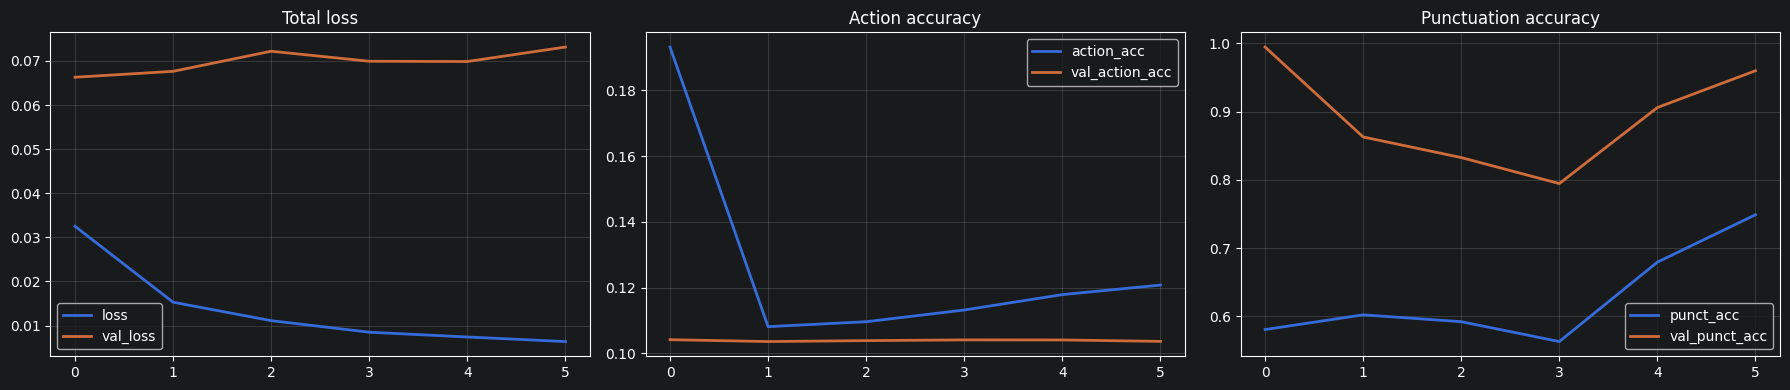

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Total loss")
axes[0].grid(True, alpha=0.3)

for col in ["action_acc", "val_action_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[1], linewidth=2, label=col)
axes[1].set_title("Action accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for col in ["punct_acc", "val_punct_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[2], linewidth=2, label=col)
axes[2].set_title("Punctuation accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluate

In [3]:
# Reload project modules before evaluation. This prevents stale Jupyter imports
# from trying to load a model with an old class definition.
reload_project_modules()

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing model config: {CONFIG_PATH}. Run training cell 16 first.")

model_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
if model_config.get("model_version", 0) < 7:
    raise RuntimeError(
        "The saved model is obsolete for the V7 runtime. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )
if not model_config.get("requires_source_punct_ids", False) or not model_config.get("requires_top_k_candidates", False):
    raise RuntimeError(
        "The saved model is from an old input format. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )

from evaluate_hybrid import evaluate_hybrid

summary = evaluate_hybrid(
    dataset_path=str(TEST_PATH),
    sample_size=EVAL_SAMPLE_SIZE,
    output_dir="report",
    strictness=STRICTNESS,
    punctuation_mode=PUNCTUATION_MODE,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    candidate_top_k=CANDIDATE_TOP_K,
    context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
    context_model_name=CONTEXT_MODEL_NAME,
    context_device=CONTEXT_DEVICE,
    context_margin=CONTEXT_MARGIN,
    use_entity_guard=USE_ENTITY_GUARD,
    deterministic_spacing=DETERMINISTIC_SPACING,
)
summary


Evaluated 50/5913 examples
Evaluated 100/5913 examples
Evaluated 150/5913 examples
Evaluated 200/5913 examples
Evaluated 250/5913 examples
Evaluated 300/5913 examples
Evaluated 350/5913 examples
Evaluated 400/5913 examples
Evaluated 450/5913 examples
Evaluated 500/5913 examples
Evaluated 550/5913 examples
Evaluated 600/5913 examples
Evaluated 650/5913 examples
Evaluated 700/5913 examples
Evaluated 750/5913 examples
Evaluated 800/5913 examples
Evaluated 850/5913 examples
Evaluated 900/5913 examples
Evaluated 950/5913 examples
Evaluated 1000/5913 examples
Evaluated 1050/5913 examples
Evaluated 1100/5913 examples
Evaluated 1150/5913 examples
Evaluated 1200/5913 examples
Evaluated 1250/5913 examples
Evaluated 1300/5913 examples
Evaluated 1350/5913 examples
Evaluated 1400/5913 examples
Evaluated 1450/5913 examples
Evaluated 1500/5913 examples
Evaluated 1550/5913 examples
Evaluated 1600/5913 examples
Evaluated 1650/5913 examples
Evaluated 1700/5913 examples
Evaluated 1750/5913 examples
Evalu

{'examples': 5913,
 'exact_match': 0.47708439032639943,
 'mean_input_cer': 0.012600259510983054,
 'mean_pred_cer': 0.008567683359832,
 'mean_cer_delta': 0.004032576151151054,
 'improved_rate': 0.2589210214780991,
 'worse_rate': 0.0015220700152207,
 'unchanged_rate': 0.7363436495856587,
 'unchanged_wrong_rate': 0.5936929893145687,
 'clean_overcorrection_rate': 0.0,
 'word_overcorrection_rate': 0.0,
 'punct_overcorrection_rate': 0.0,
 'space_overcorrection_rate': 0.0,
 'punct_input_similarity': 0.8879290950529575,
 'punct_pred_similarity': 0.8925013713400992,
 'punct_similarity_delta': 0.004572276287141741,
 'mean_punct_count_error': 0.3705394892609504,
 'mean_confidence': 0.9930447279436531,
 'accepted_rate': 0.9901911043463555,
 'spacing_only_overcorrection_rate': 0.0,
 'layout_changed_without_edits_count': 0,
 'clean_slice': {'examples': 2076,
  'exact_match': 1.0,
  'mean_input_cer': 0.0,
  'mean_pred_cer': 0.0,
  'mean_cer_delta': 0.0,
  'improved_rate': 0.0,
  'worse_rate': 0.0,
  

## 11. Analyze Reports

In [4]:
summary_path = Path("report/summary.json")
analysis_path = Path("report/error_analysis.csv")
by_type_path = Path("report/error_metrics_by_type.csv")
worst_path = Path("report/worst_cases.csv")
punct_diag_path = Path("report/punct_edit_diagnostics.csv")
word_decision_path = Path("report/word_decision_diagnostics.csv")

if summary_path.exists():
    print(summary_path.read_text(encoding="utf-8"))

analysis_df = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
by_type_df = pd.read_csv(by_type_path) if by_type_path.exists() else pd.DataFrame()
worst_df = pd.read_csv(worst_path) if worst_path.exists() else pd.DataFrame()
punct_diag_df = pd.read_csv(punct_diag_path) if punct_diag_path.exists() else pd.DataFrame()
word_decision_df = pd.read_csv(word_decision_path) if word_decision_path.exists() else pd.DataFrame()

print("Analysis rows:", len(analysis_df))
if not analysis_df.empty:
    clean_df = analysis_df[analysis_df["input_cer"] == 0]
    dirty_df = analysis_df[analysis_df["input_cer"] > 0]
    quality_rows = []
    for name, part in [("clean", clean_df), ("dirty", dirty_df), ("all", analysis_df)]:
        if part.empty:
            continue
        quality_rows.append({
            "slice": name,
            "examples": len(part),
            "mean_input_cer": part["input_cer"].mean(),
            "mean_pred_cer": part["pred_cer"].mean(),
            "mean_cer_delta": part["cer_delta"].mean(),
            "worse_rate": part["worse"].mean(),
            "clean_overcorrection_rate": part["clean_overcorrection"].mean() if name == "clean" else np.nan,
            "word_overcorrection_rate": part["word_overcorrection"].mean() if name == "clean" and "word_overcorrection" in part else np.nan,
            "punct_overcorrection_rate": part["punct_overcorrection"].mean() if name == "clean" and "punct_overcorrection" in part else np.nan,
            "spacing_only_overcorrection_rate": part["spacing_only_overcorrection"].mean() if name == "clean" and "spacing_only_overcorrection" in part else np.nan,
            "layout_changed_without_edits": part["layout_changed_without_edits"].sum() if "layout_changed_without_edits" in part else np.nan,
            "punct_similarity_delta": part["punct_pred_similarity"].mean() - part["punct_input_similarity"].mean(),
            "accepted_rate": part["accepted"].mean(),
        })
    display(pd.DataFrame(quality_rows))

if not by_type_df.empty:
    display(by_type_df.head(20))
if not worst_df.empty:
    columns = [
        "error_types", "input_cer", "pred_cer", "cer_delta", "guard_reason",
        "word_edit_count", "punct_edit_count", "error_text", "predicted_text", "correct_text",
    ]
    display(worst_df[[c for c in columns if c in worst_df.columns]].head(20))


if not word_decision_df.empty:
    print("Word decision diagnostics rows:", len(word_decision_df))
    display(word_decision_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    if "target_present_but_not_applied" in word_decision_df:
        display(word_decision_df[word_decision_df["target_present_but_not_applied"] == True].head(20))
    display(word_decision_df.head(20))

if not punct_diag_df.empty:
    print("Punctuation diagnostics rows:", len(punct_diag_df))
    display(punct_diag_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    for column in ["protected_gap", "punct_position_type", "window_conflict_resolved"]:
        if column in punct_diag_df:
            display(punct_diag_df[column].value_counts(dropna=False).head(10).to_frame("count"))
    display(punct_diag_df.head(20))

print("Full test command after training:")
print(
    "PYTHONPATH=src .venv/bin/python src/evaluate.py "
    "--dataset data/processed/test.csv --all --output-dir report/full_v7 "
    "--strictness strict --punctuation-mode conservative --candidate-top-k 8"
)


{
  "examples": 5913,
  "exact_match": 0.47708439032639943,
  "mean_input_cer": 0.012600259510983054,
  "mean_pred_cer": 0.008567683359832,
  "mean_cer_delta": 0.004032576151151054,
  "improved_rate": 0.2589210214780991,
  "worse_rate": 0.0015220700152207,
  "unchanged_rate": 0.7363436495856587,
  "unchanged_wrong_rate": 0.5936929893145687,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "space_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.8879290950529575,
  "punct_pred_similarity": 0.8925013713400992,
  "punct_similarity_delta": 0.004572276287141741,
  "mean_punct_count_error": 0.3705394892609504,
  "mean_confidence": 0.9930447279436531,
  "accepted_rate": 0.9901911043463555,
  "spacing_only_overcorrection_rate": 0.0,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 2076,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "impro

,slice,examples,mean_input_cer,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,spacing_only_overcorrection_rate,layout_changed_without_edits,punct_similarity_delta,accepted_rate
0,clean,2076,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0,0.000000,1.000000
1,dirty,3837,0.019418,0.013203,0.006214,0.002346,NaN,NaN,NaN,NaN,0,0.007046,0.984884
2,all,5913,0.012600,0.008568,0.004033,0.001522,NaN,NaN,NaN,NaN,0,0.004572,0.990191


,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,...,space_overcorrection_rate,punct_input_similarity,punct_pred_similarity,punct_similarity_delta,mean_punct_count_error,mean_confidence,accepted_rate,spacing_only_overcorrection_rate,layout_changed_without_edits_count,error_type
0,2076,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN,0.0,...,0.0,1.000000,1.000000,0.000000,0.000000,0.995062,1.000000,0.0,0,clean
1,24,0.250000,0.021116,0.016770,0.004346,0.375000,0.041667,0.583333,0.583333,NaN,...,NaN,0.900000,0.913889,0.013889,0.333333,0.994721,0.958333,NaN,0,spelling_suffix_pronunciation
2,513,0.001949,0.025492,0.020420,0.005072,0.298246,0.003899,0.693957,0.693957,NaN,...,NaN,0.528614,0.531124,0.002510,1.035088,0.991009,0.986355,NaN,0,punct_remove_final
3,113,0.079646,0.019699,0.013758,0.005940,0.380531,0.000000,0.619469,0.619469,NaN,...,NaN,0.797890,0.824523,0.026633,0.902655,0.993814,0.991150,NaN,0,punct_remove_comma_before_clause
4,171,0.023392,0.024479,0.018385,0.006094,0.333333,0.005848,0.643275,0.643275,NaN,...,NaN,0.779673,0.794686,0.015012,0.982456,0.993438,0.988304,NaN,0,punct_remove_internal_comma
5,757,0.000000,0.026018,0.019804,0.006213,0.343461,0.001321,0.638045,0.638045,NaN,...,NaN,0.789268,0.791543,0.002275,1.050198,0.991214,0.994716,NaN,0,punct_extra_comma
6,71,0.000000,0.025682,0.019388,0.006294,0.323944,0.000000,0.676056,0.676056,NaN,...,NaN,0.459427,0.459427,0.000000,1.028169,0.991290,0.985915,NaN,0,punct_remove_period
7,107,0.000000,0.023300,0.016947,0.006353,0.420561,0.000000,0.579439,0.579439,NaN,...,NaN,0.778973,0.781663,0.002690,1.056075,0.992589,1.000000,NaN,0,punct_remove_comma
8,89,0.011236,0.028795,0.020987,0.007808,0.370787,0.000000,0.617978,0.617978,NaN,...,NaN,0.681472,0.694581,0.013109,1.011236,0.993363,0.988764,NaN,0,punct_remove_all_commas
9,545,0.122936,0.028815,0.020609,0.008206,0.508257,0.001835,0.478899,0.478899,NaN,...,NaN,0.843253,0.845936,0.002683,0.511927,0.988747,0.983486,NaN,0,spelling_delete


,error_types,input_cer,pred_cer,cer_delta,guard_reason,word_edit_count,punct_edit_count,error_text,predicted_text,correct_text
0,spelling_replace,0.007937,0.031746,-0.023810,accepted,1,0,"«Газпром» — хотя в основном и государственная,...","«Газпром» — хотя в основном и государственная,...","«Газпром» — хотя в основном и государственная,..."
1,spelling_double|spelling_double|punct_remove_f...,0.060606,0.075758,-0.015152,accepted,1,0,Отдельные частички Креста разнесслись по ввсей...,Отдельные частички Креста разнесслись по в все...,Отдельные частички Креста разнеслись по всей с...
2,spelling_delete|spelling_suffix_pronunciation|...,0.035294,0.047059,-0.011765,accepted,1,0,"По словам медиков, на еле пострадавшево было з...","По словам медиков, на еле пострадавшей было за...","По словам медиков, на теле пострадавшего было ..."
3,spelling_replace,0.010417,0.020833,-0.010417,accepted,1,0,Затем этот кусочек теста или ткани мужно броси...,Затем этот кусочек теста или ткани можно броси...,Затем этот кусочек теста или ткани нужно броси...
4,spelling_swap,0.018182,0.027273,-0.009091,accepted,0,0,Восемь водзушных судов ушло на запасные аэродр...,Восемь водзушных судов ушло на запасные аэродр...,Восемь воздушных судов ушло на запасные аэродр...
5,spelling_replace,0.007874,0.015748,-0.007874,accepted,1,0,"В целом, представители риэлторских компаний бр...","В целом, представители риэлторских компаний пр...","В целом, представители риэлторских компаний пр..."
6,punct_extra_comma,0.007042,0.014085,-0.007042,accepted,0,1,"История ""Робин Гуд Гарденс"" показывает особенн...","История ""Робин Гуд Гарденс"" показывает особенн...","История ""Робин Гуд Гарденс"" показывает особенн..."
7,spelling_swap|punct_remove_internal_comma|spac...,0.024242,0.030303,-0.006061,accepted,0,1,"Однако до того момента, пока соглашение не зар...","Однако до того, момента, пока соглашение не за...","Однако до того момента, пока соглашение не зар..."
8,spelling_replace,0.005882,0.011765,-0.005882,accepted,1,0,"Он сообщил в разговоре с РИА Новости, что влад...","Он сообщил в разговоре с РИА Новости, что влад...","Он сообщил в разговоре с РИА Новости, что влад..."
9,clean,0.000000,0.000000,0.000000,accepted,0,0,"Они отсылают к двум ветхозаветным сюжетам, в к...","Они отсылают к двум ветхозаветным сюжетам, в к...","Они отсылают к двум ветхозаветным сюжетам, в к..."


Word decision diagnostics rows: 15682


...

,count
protected_gap,
False,78586
True,3642


,count
punct_position_type,
internal,73291
final,5295
protected,3642


,count
window_conflict_resolved,
False,82228


,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,index,word,source_punct,...,applied,blocked_reason,is_final,protected_gap,punct_position_type,window_id,window_conflict_resolved,text,predicted,target_text
0,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,0,Перевод,NaN,...,False,same_as_source,False,True,protected,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
1,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,1,4,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
2,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,2,декабря,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
3,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,3,ЯСвятополк,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
4,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,4,Влядимир,",",...,False,low_comma_delete_confidence_or_margin,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
5,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,5,и,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
6,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,6,Олег,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
7,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,7,заключили,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
8,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,8,нир,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."
9,0,hard,spelling_replace|spelling_extra|spelling_repla...,False,False,False,True,9,на,NaN,...,False,same_as_source,False,False,internal,0,False,"Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря ЯСвятополк Влядимир, и Оле...","Перевод: ""4 декабря Святополк, Владимир и Олег..."


Full test command after training:
PYTHONPATH=src .venv/bin/python src/evaluate.py --dataset data/processed/test.csv --all --output-dir report/full_v7 --strictness strict --punctuation-mode conservative --candidate-top-k 8


## 12. Manual Runtime Checks

In [5]:
from hybrid_corrector import HybridCorrector

corrector = HybridCorrector(strictness=STRICTNESS, punctuation_mode=PUNCTUATION_MODE, min_dictionary_score=MIN_DICTIONARY_SCORE, context_reranker_enabled=CONTEXT_RERANKER_ENABLED, context_model_name=CONTEXT_MODEL_NAME, context_device=CONTEXT_DEVICE, candidate_top_k=CANDIDATE_TOP_K, context_margin=CONTEXT_MARGIN, use_entity_guard=USE_ENTITY_GUARD, deterministic_spacing=DETERMINISTIC_SPACING)
print("Model trained:", corrector.is_trained)

sample_df = globals().get("df_test")
if sample_df is None:
    if not TEST_PATH.exists():
        raise FileNotFoundError(f"Missing test split: {TEST_PATH}. Run dataset preparation or training first.")
    sample_df = pd.read_csv(TEST_PATH)
    if "split" in sample_df.columns:
        sample_df = sample_df[sample_df["split"] == "test"].copy()
    print("Loaded test samples from disk:", len(sample_df))

if len(sample_df) > 0:
    sample_rows = sample_df.sample(min(5, len(sample_df)), random_state=SEED)
    for i, row in sample_rows.iterrows():
        result = corrector.correct(str(row["error_text"]), return_details=True)
        print("=" * 80)
        print("ERROR:  ", row["error_text"])
        print("PRED:   ", result.corrected)
        print("TARGET: ", row["correct_text"])
        print("confidence:", round(result.confidence, 3), "accepted:", result.accepted, "reason:", result.guard_reason)
        print("edits:", result.edits[:8])


Model trained: True
Loaded test samples from disk: 5913
ERROR:   По нашим данным, планируется использовать СВХ в Москве.
PRED:    По нашим данным, планируется использовать СВХ в Москве.
TARGET:  По нашим данным, планируется использовать СВХ в Москве.
confidence: 1.0 accepted: True reason: accepted
edits: []
ERROR:   Более того, существует довольно высокая вероятность того, что все последующие пакеты помощи для Украины будут намного меньше по размеру», — сказал бывший украинский офицер.
PRED:    Более того, существует довольно высокая вероятность того, что все последующие пакеты помощи для Украины будут намного меньше по размеру», — сказал бывший украинский офицер.
TARGET:  Более того, существует довольно высокая вероятность того, что все последующие пакеты помощи для Украины будут намного меньше по размеру», — сказал бывший украинский офицер.
confidence: 1.0 accepted: True reason: accepted
edits: []
ERROR:   Банкирам этот способ не нравится, но поделать они ничего не могут.
PRED:    Ба

## 13. Strictness Comparison (Optional)

This can be slow because it runs inference several times. Reduce `sample_size` if needed.


In [ ]:
RUN_STRICTNESS_COMPARISON = False
COMPARISON_SAMPLE_SIZE = 100

if RUN_STRICTNESS_COMPARISON:
    rows = []
    for mode in ["strict", "normal", "aggressive"]:
        result = evaluate_hybrid(
            dataset_path=str(TEST_PATH),
            sample_size=COMPARISON_SAMPLE_SIZE,
            output_dir=f"report/strictness_{mode}",
            strictness=mode,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
            context_device=CONTEXT_DEVICE,
            context_margin=CONTEXT_MARGIN,
            use_entity_guard=USE_ENTITY_GUARD,
            deterministic_spacing=DETERMINISTIC_SPACING,
        )
        result["strictness"] = mode
        rows.append(result)
    comparison_df = pd.DataFrame(rows)
    display(comparison_df[["strictness", "mean_pred_cer", "mean_cer_delta", "worse_rate", "clean_overcorrection_rate", "accepted_rate"]])
else:
    print("Strictness comparison skipped.")


## 14. GUI

After training, the desktop app uses the same `HybridCorrector` artifacts from `models/`.

```bash
PYTHONPATH=src .venv/bin/python app/main.py
```
